# Linear regression

Steps

1. Libraries 
2. Importing data
3. Feature engineering
4.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm



In [2]:
# Data collection

tickers = ['AAPL', 'AMZN', 'MSFT', 'QQQ', '^GSPC']
df = yf.download(tickers, start = '2020-01-01', end = '2024-12-31')['Close']
df

C:\Users\DELL\AppData\Local\Temp\ipykernel_6056\3035498316.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start = '2020-01-01', end = '2024-12-31')['Close']
[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,MSFT,QQQ,^GSPC
Date,,,,,
2020-01-02,72.620827,94.900497,153.042267,209.091080,3257.850098
2020-01-03,71.914833,93.748497,151.136658,207.175812,3234.850098
2020-01-06,72.487854,95.143997,151.527298,208.510696,3246.280029
2020-01-07,72.146950,95.343002,150.145721,208.481689,3237.179932
2020-01-08,73.307495,94.598503,152.537308,210.048691,3253.050049
...,...,...,...,...,...
2024-12-23,254.655716,225.059998,433.583038,521.505737,5974.069824
2024-12-24,257.578674,229.050003,437.647400,528.577209,6040.040039
2024-12-26,258.396667,227.050003,436.432068,528.218140,6037.589844


In [3]:

correlation_matrix = df.corr()
correlation_matrix['AAPL']

Ticker
AAPL     1.000000
AMZN     0.519411
MSFT     0.930156
QQQ      0.917248
^GSPC    0.932780
Name: AAPL, dtype: float64

In [4]:
# Step 2: Perform Feature Engineering


# Lesson: To predict AAPL Stock price, we have to consider yesterday's p
# The market is not open yet so we don't know what's the price today


# Considering Yesterday's Value
df['AAPL(t-1)'] = df['AAPL'].shift(1)
df['AMZN(t-1)'] = df['AMZN'].shift(1)
df['MSFT(t-1)'] = df['MSFT'].shift(1)
df['QQQ(t-1)'] = df['QQQ'].shift(1)
df['^GSPC(t-1)'] = df['^GSPC'].shift(1)




# Moving Avg (MA): Technical Indicator - It helps you understand the sho
df['AAPL_MA_5'] = df['AAPL'].rolling(window=5).mean()
df['AMZN_MA_5'] = df['AMZN'].rolling(window=5).mean()
df['MSFT_MA_5'] = df['MSFT'].rolling(window=5).mean()
df['QQQ_MA_5'] = df['QQQ'].rolling(window=5).mean()
df['^GSPC_MA_5'] = df['^GSPC'].rolling(window=5).mean()


# Set Y Variable - Next day
df['Target'] = df['AAPL'].shift(-1)
df = df.dropna()
df

Ticker,AAPL,AMZN,MSFT,QQQ,^GSPC,AAPL(t-1),AMZN(t-1),MSFT(t-1),QQQ(t-1),^GSPC(t-1),AAPL_MA_5,AMZN_MA_5,MSFT_MA_5,QQQ_MA_5,^GSPC_MA_5,Target
Date,,,,,,,,,,,,,,,,
2020-01-08,73.307495,94.598503,152.537308,210.048691,3253.050049,72.146950,95.343002,150.145721,208.481689,3237.179932,72.495592,94.746899,151.677850,208.661594,3245.842041,74.864632
2020-01-09,74.864632,95.052498,154.442932,211.828552,3274.699951,73.307495,94.598503,152.537308,210.048691,3253.050049,72.944353,94.777299,151.957983,209.209088,3249.212012,75.033867
2020-01-10,75.033867,94.157997,153.728333,211.286835,3265.350098,74.864632,95.052498,154.442932,211.828552,3274.699951,73.568159,94.859200,152.476318,210.031293,3255.312012,76.636917
2020-01-13,76.636917,94.565002,155.576797,213.724426,3288.129883,75.033867,94.157997,153.728333,211.286835,3265.350098,74.397972,94.743401,153.286218,211.074039,3263.681982,75.602074
2020-01-14,75.602074,93.472000,154.481033,212.882858,3283.149902,76.636917,94.565002,155.576797,213.724426,3288.129883,75.088997,94.369200,154.153281,211.954272,3272.875977,75.278069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20,253.877594,224.919998,434.927887,516.473877,5930.850098,249.188889,223.289993,435.356201,512.002808,5867.080078,250.765088,226.561996,441.715759,522.442603,5958.956055,254.655716
2024-12-23,254.655716,225.059998,433.583038,521.505737,5974.069824,253.877594,224.919998,434.927887,516.473877,5930.850098,251.609055,224.987997,438.460284,519.563428,5938.954004,257.578674
2024-12-24,257.578674,229.050003,437.647400,528.577209,6040.040039,254.655716,225.059998,433.583038,521.505737,5974.069824,252.550790,224.567999,435.445874,518.570544,5936.840039,258.396667


In [5]:
# Step 3: Fit a Linear Regression Model


# Set X and Y variable for Linear Regression Model - Ordinary Least Square

X = df[['AAPL(t-1)', 'AMZN(t-1)',
 'MSFT(t-1)', 'QQQ(t-1)', '^GSPC(t-1)', 'AAPL_MA_5', 'AMZN_MA_5',
 'MSFT_MA_5', 'QQQ_MA_5', '^GSPC_MA_5']]

Y = df['Target']

X_const = sm.add_constant(X) # Intercept Term

# Train the Model
model = sm.OLS(Y, X_const).fit()

# Summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Target   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 1.644e+04
Date:                Sun, 27 Jul 2025   Prob (F-statistic):               0.00
Time:                        10:14:35   Log-Likelihood:                -3383.9
No. Observations:                1252   AIC:                             6790.
Df Residuals:                    1241   BIC:                             6846.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5109      1.146      0.446      0.656      -1.737       2.759
AAPL(t-1)      0.4682      0.081      5.764      0.000       0.309       0.628
AMZN(t-1)      0.0646      0.067      0.958      0.338      -0.068       0.197
MSFT(t-1)     -0.0165      0.052     -0.314      0.753      -0.119       0.086
QQQ(t-1)       0.0091      0.102      0.089      0.929      -0.190       0.208
^GSPC(t-1)     0.0053      0.007      0.734      0.463      -0.009       0.019
AAPL_MA_5      0.5158      0.082      6.279      0.000       0.355       0.677
AMZN_MA_5     -0.0594      0.069     -0.866      0.386      -0.194       0.075
MSFT_MA_5      0.0281      0.053      0.531      0.595      -0.076       0.132
QQQ_MA_5      -0.0099      0.104     -0.096      0.924      -0.213       0.194
^GSPC_MA_5    -0.0056      0.007     -0.776      0.438      -0.020       0.009
==============================================================================
Omnibus:                       26.037   Durbin-Watson:                   0.808
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.707
Skew:                          -0.085   Prob(JB):                     1.61e-11
Kurtosis:                       3.961   Cond. No.                     6.88e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.88e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

coeff= value of beta in lr model


st error= how much the difference can be in slope of predicted value (suppose predicted salar is 1.2l,On average,
                                                                     if we were to collect many      
                                                                     random samples and refit the model, 
                                                                    the slope could vary within ±0.3 of that 1.2.)


The t-value tells you how strongly your coefficient differs from 0.
Large t-value (typically |t| > 2) → significant variable
Small t-value (|t| < 2) → weak or no evidence that variable affects target



In [6]:

X = df[['AAPL(t-1)', '^GSPC(t-1)']] # Dropping AAPL_MA_5

Y = df['Target']
X_const = sm.add_constant(X) # Intercept Term



model = sm.OLS(Y, X_const).fit()


model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Target   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 7.762e+04
Date:                Sun, 27 Jul 2025   Prob (F-statistic):               0.00
Time:                        10:14:39   Log-Likelihood:                -3423.4
No. Observations:                1252   AIC:                             6853.
Df Residuals:                    1249   BIC:                             6868.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7187      0.750     -0.959      0.338      -2.189       0.752
AAPL(t-1)      0.9840      0.007    140.621      0.000       0.970       0.998
^GSPC(t-1)     0.0008      0.000      2.114      0.035    5.81e-05       0.002
==============================================================================
Omnibus:                       40.865   Durbin-Watson:                   1.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              103.864
Skew:                          -0.036   Prob(JB):                     2.79e-23
Kurtosis:                       4.409   Cond. No.                     3.08e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.08e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [7]:
# calculate acutal vs predicted


df_train_predict = pd.DataFrame()
df_train_predict['Actual'] = df['Target']
df_train_predict['Predicted'] = model.predict(X_const)
df_train_predict

,Actual,Predicted
Date,,
2020-01-08,74.864632,72.887285
2020-01-09,75.033867,74.042080
2020-01-10,76.636917,75.591789
2020-01-13,75.602074,75.750771
2020-01-14,75.278069,77.346572
...,...,...
2024-12-20,254.655716,249.220624
2024-12-23,257.578674,253.885818
2024-12-24,258.396667,254.686380


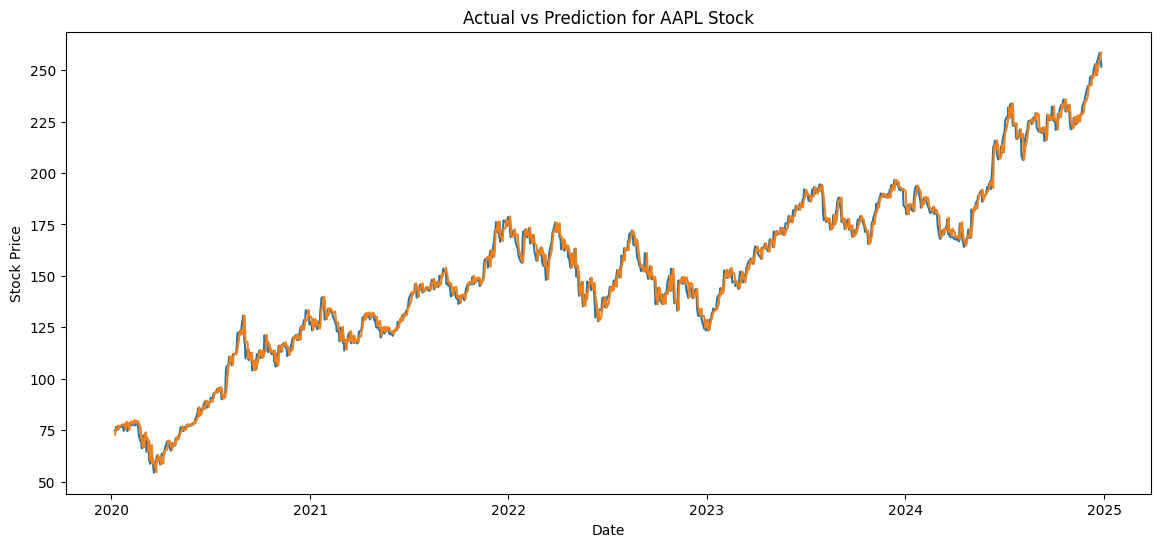

In [8]:
# Plot between Actual vs Predicted Value



import matplotlib.pyplot as plt

plt.figure(figsize = (14,6))
plt.plot(df_train_predict.index, df_train_predict['Actual'], label = 'Actual')
plt.plot(df_train_predict.index, df_train_predict['Predicted'], label ='predicted')
plt.title("Actual vs Prediction for AAPL Stock")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.show()


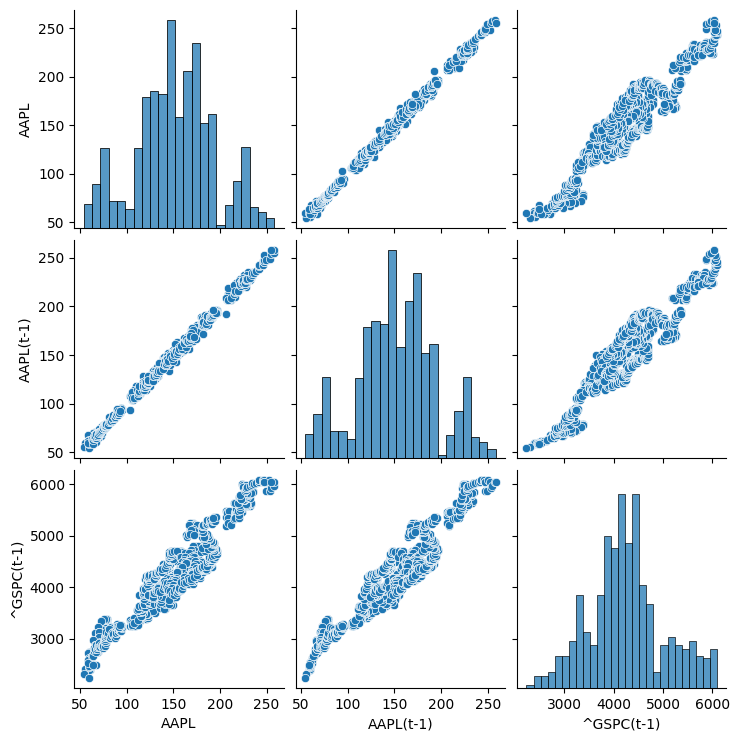

In [9]:
# Assumptions of Linear Regression:

# 1) Linearity between dependent and independent variable - Met

import seaborn as sns


df = df[['AAPL', 'AAPL(t-1)', '^GSPC(t-1)']]
sns.pairplot(df)



# AAPL & AAPL(t-1) has linear relationship
# AAPL & S&P500 has linear relationship
# AAPL & AAPL_MA_5 has linear relationship

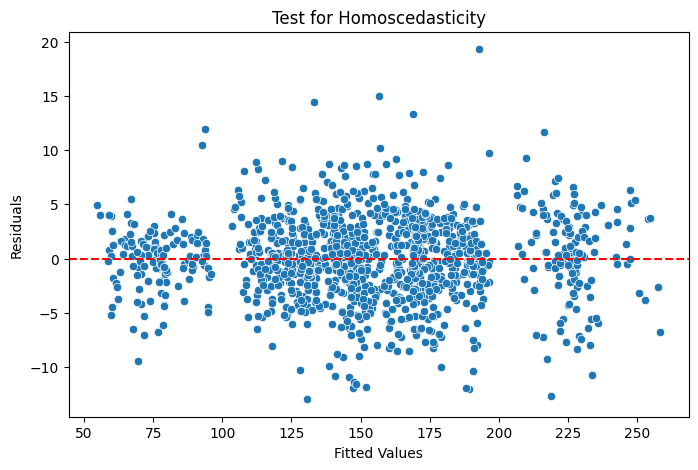

In [10]:
# 2) Homoscedasticity: Fitting Residual with the predicted value


residual = model.resid # Actual - Predicted
fitted = model.fittedvalues # Predicted Y Value


plt.figure(figsize = (8,5))
sns.scatterplot(x = fitted, y = residual)
plt.axhline(0, color = 'red', linestyle = '--')
plt.title('Test for Homoscedasticity')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


# Since it's a tube like structure => It is homoscedastic -> Assumption i
# If it was funnel like structure => It is heteroscedastic

In [11]:
# 3) Multicollinearity => VIF (Variance Inflation Factor) => For independent variable

# Rule of thumb for VIF
# VIF < 1 => No Multicollinearity
# VIF < 10 => Moderate Multicollinearity
# VIF > 10 => Strong Multicollinearity
# VIF = Condition is Met

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif['Features'] = X_const.columns
vif['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif = vif[1:]
vif

,Features,VIF
1,AAPL(t-1),7.634911
2,^GSPC(t-1),7.634911


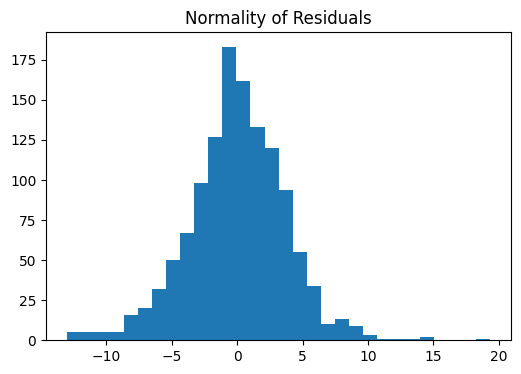

In [12]:
# 4) Assumption: Normality of Residual => 1) Visual Test (Histogram) or QQ plot


plt.figure(figsize = (6,4))
plt.hist(residual, bins = 30)
plt.title("Normality of Residuals")
plt.show()

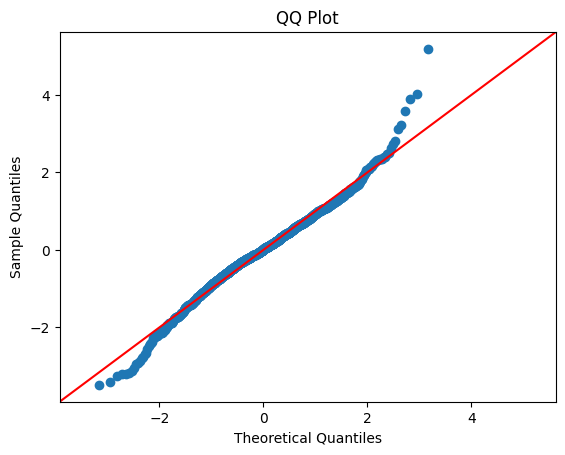

In [13]:
# QQ Plot for testing Normality of Residuals


sm.qqplot(residual, line = '45', fit = True)
plt.title('QQ Plot')
plt.show()


In [14]:
# Test 5: Auto correlation of Residual: Durbin Watson Test

from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residual)
dw # p value

# p value < 0.05 => Autocorrelation b/w residual is there
# p value > 0.05 => Autocorrelation b/w residual is not there

# Our 5th condition is met

1.0410070656445296

## Predict the Stock Price for the Year 2025


In [15]:
# Step 1: Download the data from Yahoo Finance

tickers = ['AAPL', '^GSPC']
df = yf.download(tickers, start = '2025-01-01', end = '2025-03-31')['Close']
df

C:\Users\DELL\AppData\Local\Temp\ipykernel_6056\2178015344.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start = '2025-01-01', end = '2025-03-31')['Close']
[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,^GSPC
Date,,
2025-01-02,243.263199,5868.549805
2025-01-03,242.774368,5942.470215
2025-01-06,244.410416,5975.379883
2025-01-07,241.627136,5909.029785
2025-01-08,242.115952,5918.250000
2025-01-10,236.280045,5827.040039
2025-01-13,233.835922,5836.220215
2025-01-14,232.718613,5842.910156
2025-01-15,237.297562,5949.910156


In [16]:
# Step 2: Data Eng

df['AAPL(t-1)'] = df['AAPL'].shift(1)
df['^GSPC(t-1)'] = df['^GSPC'].shift(1)
df = df.dropna()
df.head()


Ticker,AAPL,^GSPC,AAPL(t-1),^GSPC(t-1)
Date,,,,
2025-01-03,242.774368,5942.470215,243.263199,5868.549805
2025-01-06,244.410416,5975.379883,242.774368,5942.470215
2025-01-07,241.627136,5909.029785,244.410416,5975.379883
2025-01-08,242.115952,5918.250000,241.627136,5909.029785
2025-01-10,236.280045,5827.040039,242.115952,5918.250000


In [17]:


X_test = df[['AAPL(t-1)', '^GSPC(t-1)']]
X_test = sm.add_constant(X_test)
df_result = pd.DataFrame()
df_result['Actual'] = df['AAPL']
df_result['Predicted'] = model.predict(X_test)
df_result.head()


,Actual,Predicted
Date,,
2025-01-03,242.774368,243.390885
2025-01-06,244.410416,242.969536
2025-01-07,241.627136,244.605982
2025-01-08,242.115952,241.813660
2025-01-10,236.280045,242.302100


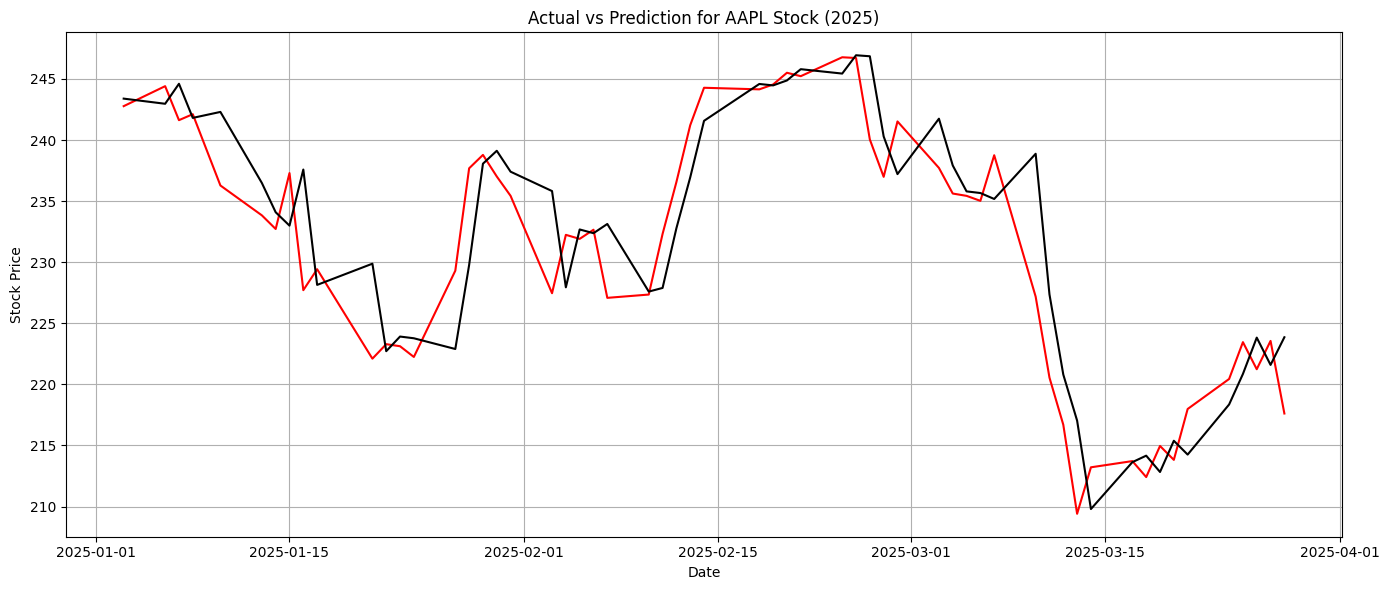

In [18]:
# Plot between Actual vs Predicted Value
import matplotlib.pyplot as plt
plt.figure(figsize = (14,6))
plt.plot(df_result.index, df_result['Actual'], label = 'Actual', color = 'red')
plt.plot(df_result.index, df_result['Predicted'], label = 'Predicted', color='black')
plt.title("Actual vs Prediction for AAPL Stock (2025)")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
# calculate RMSE and MSE
# RMSE  - root mean sq error =  Sq root(Avg((A - P)^2))
# mse = mean square error => Avg((A - P)^2)

from sklearn.metrics import mean_squared_error
import numpy as np
# Calculate mse
mse = mean_squared_error(df_result['Actual'], df_result['Predicted'])
rmse = np.sqrt(mse)
print(rmse, mse)



4.16014997245449 17.306847793313093


# 📌 Lasso Regression



1: Import all the required libraries

2: Define Features and Target Variables

3: Train Test Split

4: Apply Lasso Regression

5: Get Intercept and Coeff for Lasso Regression

6: Predict using Lasso Regression

7: Create a dataframe with Actual and Predicted Values

8: Plot Actual & Predicted Values

9: Evaluate the Model - R square, mse, rmse


In [20]:
tickers = ['AAPL', 'AMZN', 'MSFT', 'QQQ', '^GSPC']
df = yf.download(tickers, start = '2020-01-01', end = '2025-04-01')['Close']
df

C:\Users\DELL\AppData\Local\Temp\ipykernel_6056\4206444516.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start = '2020-01-01', end = '2025-04-01')['Close']
[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,MSFT,QQQ,^GSPC
Date,,,,,
2020-01-02,72.620842,94.900497,153.042282,209.091095,3257.850098
2020-01-03,71.914803,93.748497,151.136688,207.175812,3234.850098
2020-01-06,72.487869,95.143997,151.527298,208.510696,3246.280029
2020-01-07,72.146935,95.343002,150.145752,208.481659,3237.179932
2020-01-08,73.307503,94.598503,152.537277,210.048721,3253.050049
...,...,...,...,...,...
2025-03-25,223.456970,205.710007,394.435883,492.906433,5776.649902
2025-03-26,221.239868,201.130005,389.255402,483.836609,5712.200195
2025-03-27,223.556839,201.360001,389.864258,481.079712,5693.310059


In [21]:
# Perform Feature Engineering


# Lesson: To predict AAPL Stock price, we have to consider yesterday's price
# The market is not open yet so we don't know what's the price today


# Considering Yesterday's Value
df['AAPL(t-1)'] = df['AAPL'].shift(1)
df['AMZN(t-1)'] = df['AMZN'].shift(1)
df['MSFT(t-1)'] = df['MSFT'].shift(1)
df['QQQ(t-1)'] = df['QQQ'].shift(1)
df['^GSPC(t-1)'] = df['^GSPC'].shift(1)




# Moving Avg (MA): Technical Indicator - It helps you understand the short term trend
df['AAPL_MA_5'] = df['AAPL'].rolling(window=5).mean()
df['AMZN_MA_5'] = df['AMZN'].rolling(window=5).mean()
df['MSFT_MA_5'] = df['MSFT'].rolling(window=5).mean()
df['QQQ_MA_5'] = df['QQQ'].rolling(window=5).mean()
df['^GSPC_MA_5'] = df['^GSPC'].rolling(window=5).mean()


# Set Y Variable - Next day
df['Target'] = df['AAPL'].shift(-1)
df = df.dropna()
df

Ticker,AAPL,AMZN,MSFT,QQQ,^GSPC,AAPL(t-1),AMZN(t-1),MSFT(t-1),QQQ(t-1),^GSPC(t-1),AAPL_MA_5,AMZN_MA_5,MSFT_MA_5,QQQ_MA_5,^GSPC_MA_5,Target
Date,,,,,,,,,,,,,,,,
2020-01-08,73.307503,94.598503,152.537277,210.048721,3253.050049,72.146935,95.343002,150.145752,208.481659,3237.179932,72.495590,94.746899,151.677859,208.661597,3245.842041,74.864616
2020-01-09,74.864616,95.052498,154.442963,211.828506,3274.699951,73.307503,94.598503,152.537277,210.048721,3253.050049,72.944345,94.777299,151.957996,209.209079,3249.212012,75.033875
2020-01-10,75.033875,94.157997,153.728317,211.286835,3265.350098,74.864616,95.052498,154.442963,211.828506,3274.699951,73.568159,94.859200,152.476321,210.031284,3255.312012,76.636902
2020-01-13,76.636902,94.565002,155.576813,213.724426,3288.129883,75.033875,94.157997,153.728317,211.286835,3265.350098,74.397966,94.743401,153.286224,211.074030,3263.681982,75.602074
2020-01-14,75.602074,93.472000,154.481064,212.882904,3283.149902,76.636902,94.565002,155.576813,213.724426,3288.129883,75.088994,94.369200,154.153287,211.954279,3272.875977,75.278084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-24,220.440918,203.259995,392.359680,490.109558,5767.569824,217.984146,196.210007,390.543030,479.585388,5667.560059,215.922849,196.556000,387.792072,480.128320,5677.594043,223.456970
2025-03-25,223.456970,205.710007,394.435883,492.906433,5776.649902,220.440918,203.259995,392.359680,490.109558,5767.569824,218.131952,199.134000,390.115808,484.049237,5709.991992,221.239868
2025-03-26,221.239868,201.130005,389.255402,483.836609,5712.200195,223.456970,205.710007,394.435883,492.906433,5776.649902,219.388303,200.252002,390.545020,484.889502,5717.374023,223.556839


In [22]:
# Step 1: Import all the required libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [23]:
# Step 2: Define Features and Target Variables

X = df[['AAPL(t-1)', 'AMZN(t-1)',
 'MSFT(t-1)', 'QQQ(t-1)', '^GSPC(t-1)', 'AAPL_MA_5', 'AMZN_MA_5',
 'MSFT_MA_5', 'QQQ_MA_5', '^GSPC_MA_5']]

Y = df['Target']


In [24]:
# Step 3: Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.05, shuffle=False)

In [25]:
# Step 4: Apply Lasso Regression
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 10)
lasso.fit(X_train, Y_train) # Train the model

,alpha,10
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [26]:
# Step 5: Get Intercept and Coeff for Lasso Regression
coefficients = lasso.coef_
coefficients
intercept = lasso.intercept_
intercept
coeff_df = pd.DataFrame({'Feature':X.columns, 'Coefficients':coefficients})
coeff_df


,Feature,Coefficients
0,AAPL(t-1),0.572483
1,AMZN(t-1),-0.000000
2,MSFT(t-1),0.005909
3,QQQ(t-1),0.000000
4,^GSPC(t-1),0.002469
5,AAPL_MA_5,0.367736
6,AMZN_MA_5,-0.000000
7,MSFT_MA_5,0.000000
8,QQQ_MA_5,0.000000
9,^GSPC_MA_5,0.000000


In [27]:
# Step 6: Predict using Lasso Regression
y_pred = lasso.predict(X_test)
y_pred


array([249.13301846, 252.28252049, 253.17307085, 255.83820315,
       256.71880616, 254.38245429, 251.89921299, 249.74768661,
       244.79707295, 243.95084746, 244.26224323, 241.90634858,
       241.70825467, 237.45164859, 235.20484071, 234.25434518,
       236.14309893, 230.10949897, 230.40164615, 225.64309945,
       225.47600275, 225.05970919, 224.48958607, 229.40347101,
       235.5514411 , 237.10293049, 236.97977568, 235.86074548,
       230.75913883, 233.10470741, 232.6593158 , 232.54296895,
       229.16452447, 229.43886901, 232.62282196, 235.62693309,
       239.72068017, 242.69783976, 243.56733003, 244.52030641,
       245.31160812, 245.03066462, 246.00700793, 245.53631441,
       241.10339316, 238.80559631, 240.99084136, 237.68763093,
       235.97162724, 235.95071891, 235.23140548, 236.65190228,
       228.45524774, 223.17778705, 219.17075136, 212.89962198,
       214.43550793, 214.21863026, 213.16200551, 215.11965639,
       214.78257595, 217.69862611, 220.17514599, 222.39

In [28]:
# Step 7: Create a dataframe with Actual and Predicted Values
df_result = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred})
df_result

,Actual,Predicted
Date,,
2024-12-20,254.655716,249.133018
2024-12-23,257.578674,252.282520
2024-12-24,258.396667,253.173071
2024-12-26,254.974930,255.838203
2024-12-27,251.593079,256.718806
...,...,...
2025-03-24,223.456970,217.698626
2025-03-25,221.239868,220.175146
2025-03-26,223.556839,222.398480


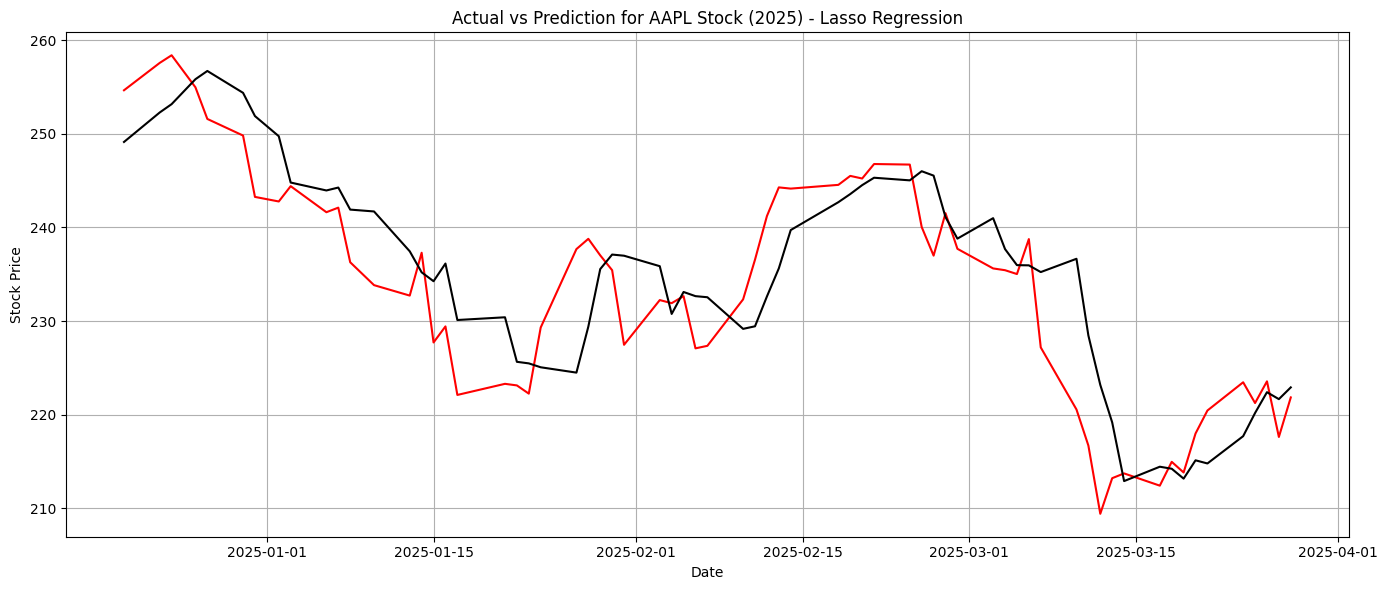

In [29]:
# Step 8: Plot Actual & Predicted Values
import matplotlib.pyplot as plt
plt.figure(figsize = (14,6))
plt.plot(df_result.index, df_result['Actual'], label = 'Actual', color ='red')
plt.plot(df_result.index, df_result['Predicted'], label = 'Predicted', color='black')
plt.title("Actual vs Prediction for AAPL Stock (2025) - Lasso Regression")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# Step 9: Evaluate the Model - R square, mse, rmse
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(Y_test, y_pred)
print("R square", r2)
mse = mean_squared_error(Y_test, y_pred)
print("mse",mse)
rmse = np.sqrt(mse)
print("rmse", rmse)

R square 0.7598493834694228
mse 33.88100976379984
rmse 5.8207396234327335


# 📌 Ridge Regression

1: Import all the required libraries

2: Define Features and Target Variables

3: Train Test Split

4: Apply  Ridge Regression

5: Get Intercept and Coeff for Ridge Regression

6: Predict using Ridge Regression

7: Create a dataframe with Actual and Predicted Values

8: Plot Actual & Predicted Values

9: Evaluate the Model - R square, mse, rmse


In [31]:
# Step 1: Import all the required libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


In [32]:
# Step 2: Define Features and Target Variables
X = df[['AAPL(t-1)', 'AMZN(t-1)',
 'MSFT(t-1)', 'QQQ(t-1)', '^GSPC(t-1)', 'AAPL_MA_5', 'AMZN_MA_5',
 'MSFT_MA_5', 'QQQ_MA_5', '^GSPC_MA_5']]
Y = df['Target']


In [33]:
# Step 3: Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.05, shuffle=False)

In [34]:
# Step 4: Apply Ridge Regression
from sklearn.linear_model import Ridge
ridge = Ridge(alpha = 10)
ridge.fit(X_train, Y_train) # Train the model


,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [35]:
# Step 5: Get Intercept and Coeff for Lasso Regression
coefficients = ridge.coef_
coefficients
intercept = ridge.intercept_
intercept
coeff_df = pd.DataFrame({'Feature':X.columns, 'Coefficients':coefficients})
coeff_df

,Feature,Coefficients
0,AAPL(t-1),0.450881
1,AMZN(t-1),0.054306
2,MSFT(t-1),-0.017306
3,QQQ(t-1),0.034673
4,^GSPC(t-1),0.004590
5,AAPL_MA_5,0.532350
6,AMZN_MA_5,-0.049470
7,MSFT_MA_5,0.029150
8,QQQ_MA_5,-0.035692
9,^GSPC_MA_5,-0.004928


In [36]:
# Step 6: Predict using Ridge Regression
y_pred = ridge.predict(X_test)
y_pred


array([249.33406911, 252.62537896, 253.86004787, 256.71460003,
       257.37798685, 255.00035874, 252.54218347, 250.17975951,
       245.67687807, 245.02078182, 245.14139307, 242.15983659,
       241.7228733 , 237.58361011, 235.52264788, 234.51970346,
       236.07512013, 230.44226702, 230.34618986, 226.23483823,
       225.31086493, 224.54671986, 223.94513188, 228.07995606,
       234.03486394, 235.80892422, 236.89497829, 235.81287871,
       231.11028874, 232.95427838, 232.1011183 , 231.91019132,
       228.36757067, 229.10724664, 231.84488615, 234.41482343,
       238.75019176, 241.85640143, 243.00346687, 244.09654149,
       244.81140866, 244.27768773, 245.1903225 , 244.84085982,
       241.54305747, 238.82503365, 240.99980651, 237.32596229,
       235.70830388, 236.2780594 , 234.90455501, 236.17965811,
       228.35154335, 223.64791353, 219.8847757 , 213.23112912,
       214.40188918, 213.90838698, 212.45872192, 214.467677  ,
       214.33052604, 216.79057382, 219.89029716, 222.04

In [37]:
# Step 7: Create a dataframe with Actual and Predicted Values
df_result = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred})
df_result

,Actual,Predicted
Date,,
2024-12-20,254.655716,249.334069
2024-12-23,257.578674,252.625379
2024-12-24,258.396667,253.860048
2024-12-26,254.974930,256.714600
2024-12-27,251.593079,257.377987
...,...,...
2025-03-24,223.456970,216.790574
2025-03-25,221.239868,219.890297
2025-03-26,223.556839,222.045607


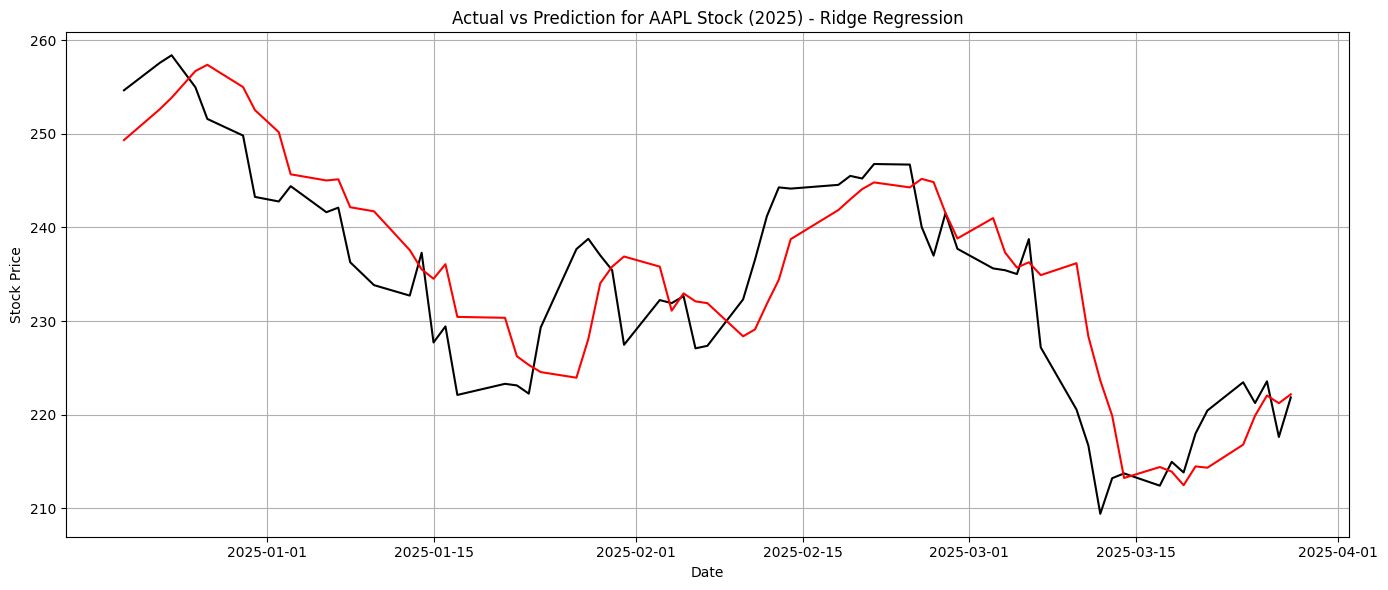

In [38]:
# Step 8: Plot Actual & Predicted Values
import matplotlib.pyplot as plt
plt.figure(figsize = (14,6))
plt.plot(df_result.index, df_result['Actual'], label = 'Actual', color ='black')
plt.plot(df_result.index, df_result['Predicted'], label = 'Predicted', color='red')
plt.title("Actual vs Prediction for AAPL Stock (2025) - Ridge Regression")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
# Step 9: Evaluate the Model - R square, mse, rmse
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(Y_test, y_pred)
print("R square", r2)
mse = mean_squared_error(Y_test, y_pred)
print("mse",mse)
rmse = np.sqrt(mse)
print("rmse", rmse)


R square 0.744373548146517
mse 36.06437674929149
rmse 6.005362332889789


# 📌 Elastic net  Regression

In [40]:
# Step 1: Import all the required libraries
# Step 2: Define Features and Target Variables
# Step 3: Train Test Split
# Step 4: Apply Elastic Net Regression
# Step 5: Get Intercept and Coeff for Elastic Net Regression
# Step 6: Predict using Elastic Net Regression
# Step 7: Create a dataframe with Actual and Predicted Values
# Step 8: Plot Actual & Predicted Values
# Step 9: Evaluate the Model - R square, mse, rmse


In [41]:
# Step 1: Import all the required libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [42]:
# Step 2: Define Features and Target Variables
X = df[['AAPL(t-1)', 'AMZN(t-1)',
 'MSFT(t-1)', 'QQQ(t-1)', '^GSPC(t-1)', 'AAPL_MA_5', 'AMZN_MA_5',
 'MSFT_MA_5', 'QQQ_MA_5', '^GSPC_MA_5']]
Y = df['Target']

In [43]:
# Step 3: Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.05, shuffle=False)

In [44]:
# Step 4: Apply Elastic Net Regression

from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha = 1, l1_ratio = 0.5)
elastic_net.fit(X_train, Y_train) #Train the model


# alpha = 1, alpha control the strength of regularization (higher alpha = stronger penalty) - Lambda parameter
# l1_ratio = 0.5 => applying 50% lasso and 50% as ridge regression - alpha parameter(maths)

c:\Users\DELL\Desktop\python\regressionmode\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.467e+03, tolerance: 2.125e+02
  model = cd_fast.enet_coordinate_descent(


,alpha,1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [45]:
# Step 5: Get Intercept and Coeff for Lasso Regression
coefficients = elastic_net.coef_
coefficients
intercept = elastic_net.intercept_
intercept
coeff_df = pd.DataFrame({'Feature':X.columns, 'Coefficients':coefficients})
coeff_df

,Feature,Coefficients
0,AAPL(t-1),0.529562
1,AMZN(t-1),0.000293
2,MSFT(t-1),0.010716
3,QQQ(t-1),0.002977
4,^GSPC(t-1),0.006588
5,AAPL_MA_5,0.447656
6,AMZN_MA_5,0.000000
7,MSFT_MA_5,0.000000
8,QQQ_MA_5,0.000000
9,^GSPC_MA_5,-0.006787


In [46]:
# Step 7: Create a dataframe with Actual and Predicted Values
df_result = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred})
df_result

,Actual,Predicted
Date,,
2024-12-20,254.655716,249.334069
2024-12-23,257.578674,252.625379
2024-12-24,258.396667,253.860048
2024-12-26,254.974930,256.714600
2024-12-27,251.593079,257.377987
...,...,...
2025-03-24,223.456970,216.790574
2025-03-25,221.239868,219.890297
2025-03-26,223.556839,222.045607


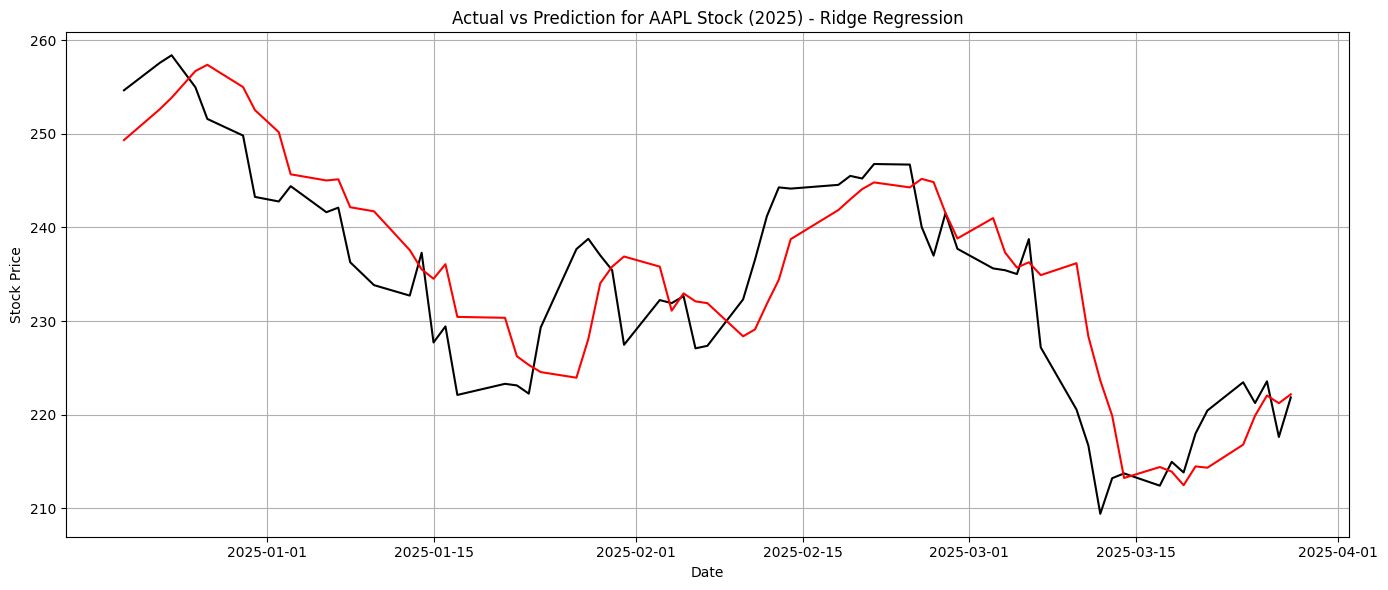

In [47]:
# Step 8: Plot Actual & Predicted Values
import matplotlib.pyplot as plt
plt.figure(figsize = (14,6))
plt.plot(df_result.index, df_result['Actual'], label = 'Actual', color ='black')
plt.plot(df_result.index, df_result['Predicted'], label = 'Predicted', color='red')
plt.title("Actual vs Prediction for AAPL Stock (2025) - Ridge Regression")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
# Step 9: Evaluate the Model - R square, mse, rmse
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(Y_test, y_pred)
print("R square", r2)
mse = mean_squared_error(Y_test, y_pred)
print("mse",mse)
rmse = np.sqrt(mse)
print("rmse", rmse)


R square 0.744373548146517
mse 36.06437674929149
rmse 6.005362332889789
